In [887]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [888]:
using Revise
using Newtrinos
using Newtrinos.osc


In [889]:
# STANDARD MODEL

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);


[ Info: Loading Gerda data


In [890]:
par= Newtrinos.get_params(experiments)

(m₀ = 0.1, Δm²₂₁ = 7.53e-5, Δm²₃₁ = -0.0024, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [891]:


matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par);

In [892]:
# Effective Majorana mass in SM

mass=Newtrinos.gerda.get_neutrinomass_SM(osc_cfg.flavour)(par)

0.1112182914858422

In [893]:
# NNATURALNESS

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);

par= Newtrinos.get_params(experiments)

#matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par)

[ Info: Loading Gerda data


(N = 30.0, m₀ = 0.1, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = -0.0024, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [894]:

time_nnm=Newtrinos.gerda.get_halftime(par)

(::Newtrinos.gerda.var"#halftime#59"{@NamedTuple{N::Float64, m₀::Float64, r::Float64, Δm²₂₁::Float64, Δm²₃₁::Float64, δCP::Float64, θ₁₂::Float64, θ₁₃::Float64, θ₂₃::Float64}}) (generic function with 1 method)

In [895]:
# Effective Majorana mass in nnm

mass=Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par)

0.118686592584466

In [896]:

all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = ( r=31,  m₀=31)  

modified_priors = (
    N = par.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    


(N = 30.0, m₀ = Uniform{Float64}(a=1.0e-7, b=0.3), r = Uniform{Float64}(a=0.0, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=-0.003, b=-0.002), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [897]:
likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

Progress:  20%|████████▏                                |  ETA: 0:00:00

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


NewtrinosResult((r = [0.0, 0.03333333333333333, 0.06666666666666667, 0.1, 0.13333333333333333, 0.16666666666666666, 0.2, 0.23333333333333334, 0.26666666666666666, 0.3  …  0.7, 0.7333333333333333, 0.7666666666666667, 0.8, 0.8333333333333334, 0.8666666666666667, 0.9, 0.9333333333333333, 0.9666666666666667, 1.0], m₀ = [1.0e-7, 0.010000096666666666, 0.020000093333333333, 0.03000009, 0.04000008666666667, 0.050000083333333334, 0.060000080000000004, 0.07000007666666666, 0.08000007333333334, 0.09000007  …  0.21000002999999998, 0.22000002666666665, 0.23000002333333333, 0.24000002, 0.25000001666666666, 0.26000001333333334, 0.27000001, 0.28000000666666663, 0.2900000033333333, 0.3]), (N = [30.0 30.0 … 30.0 30.0; 30.0 30.0 … 30.0 30.0; … ; 30.0 30.0 … 30.0 30.0; 30.0 30.0 … 30.0 30.0], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [-0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.0024 … 

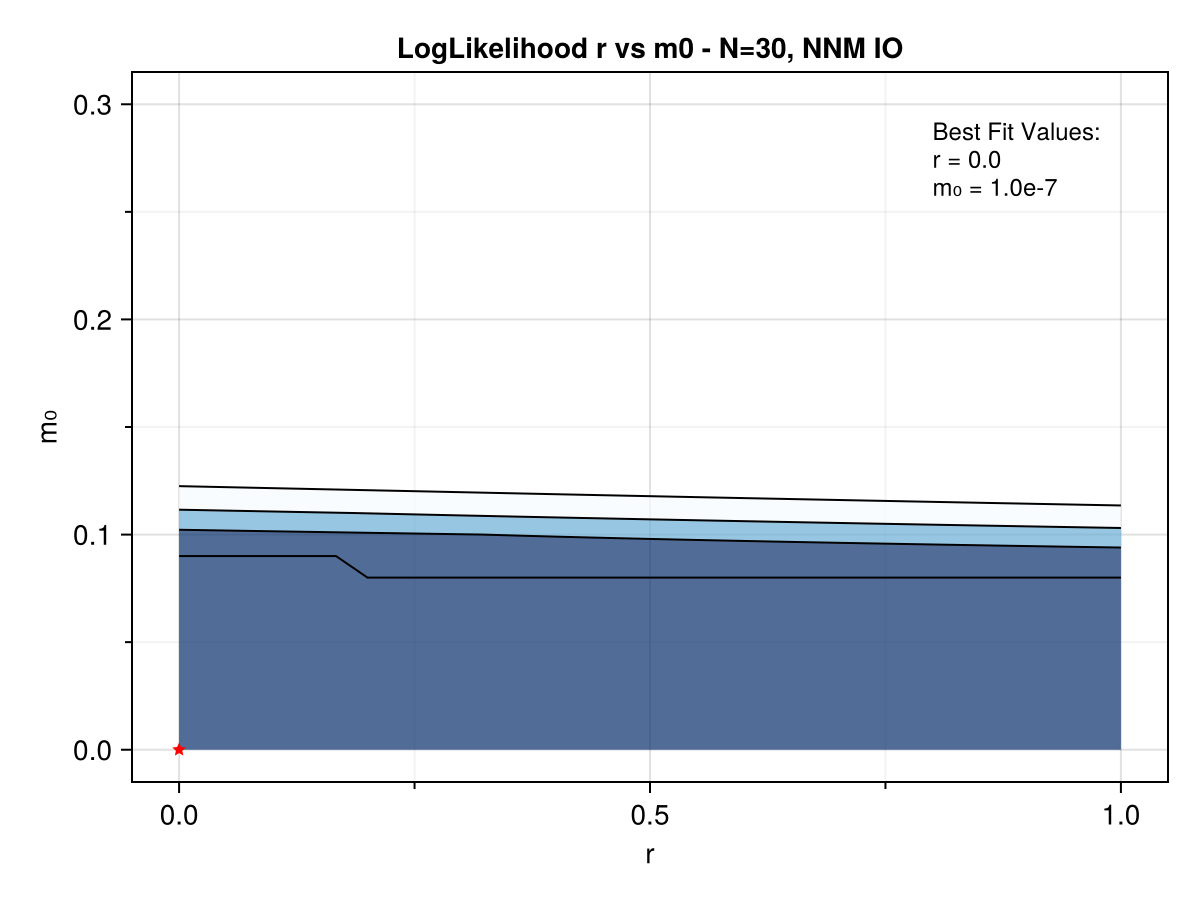

In [898]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="LogLikelihood r vs m0 - N=30, NNM IO")
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/gerda_rm0_N30_NNM_IO.png", img)

rindex: 1


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


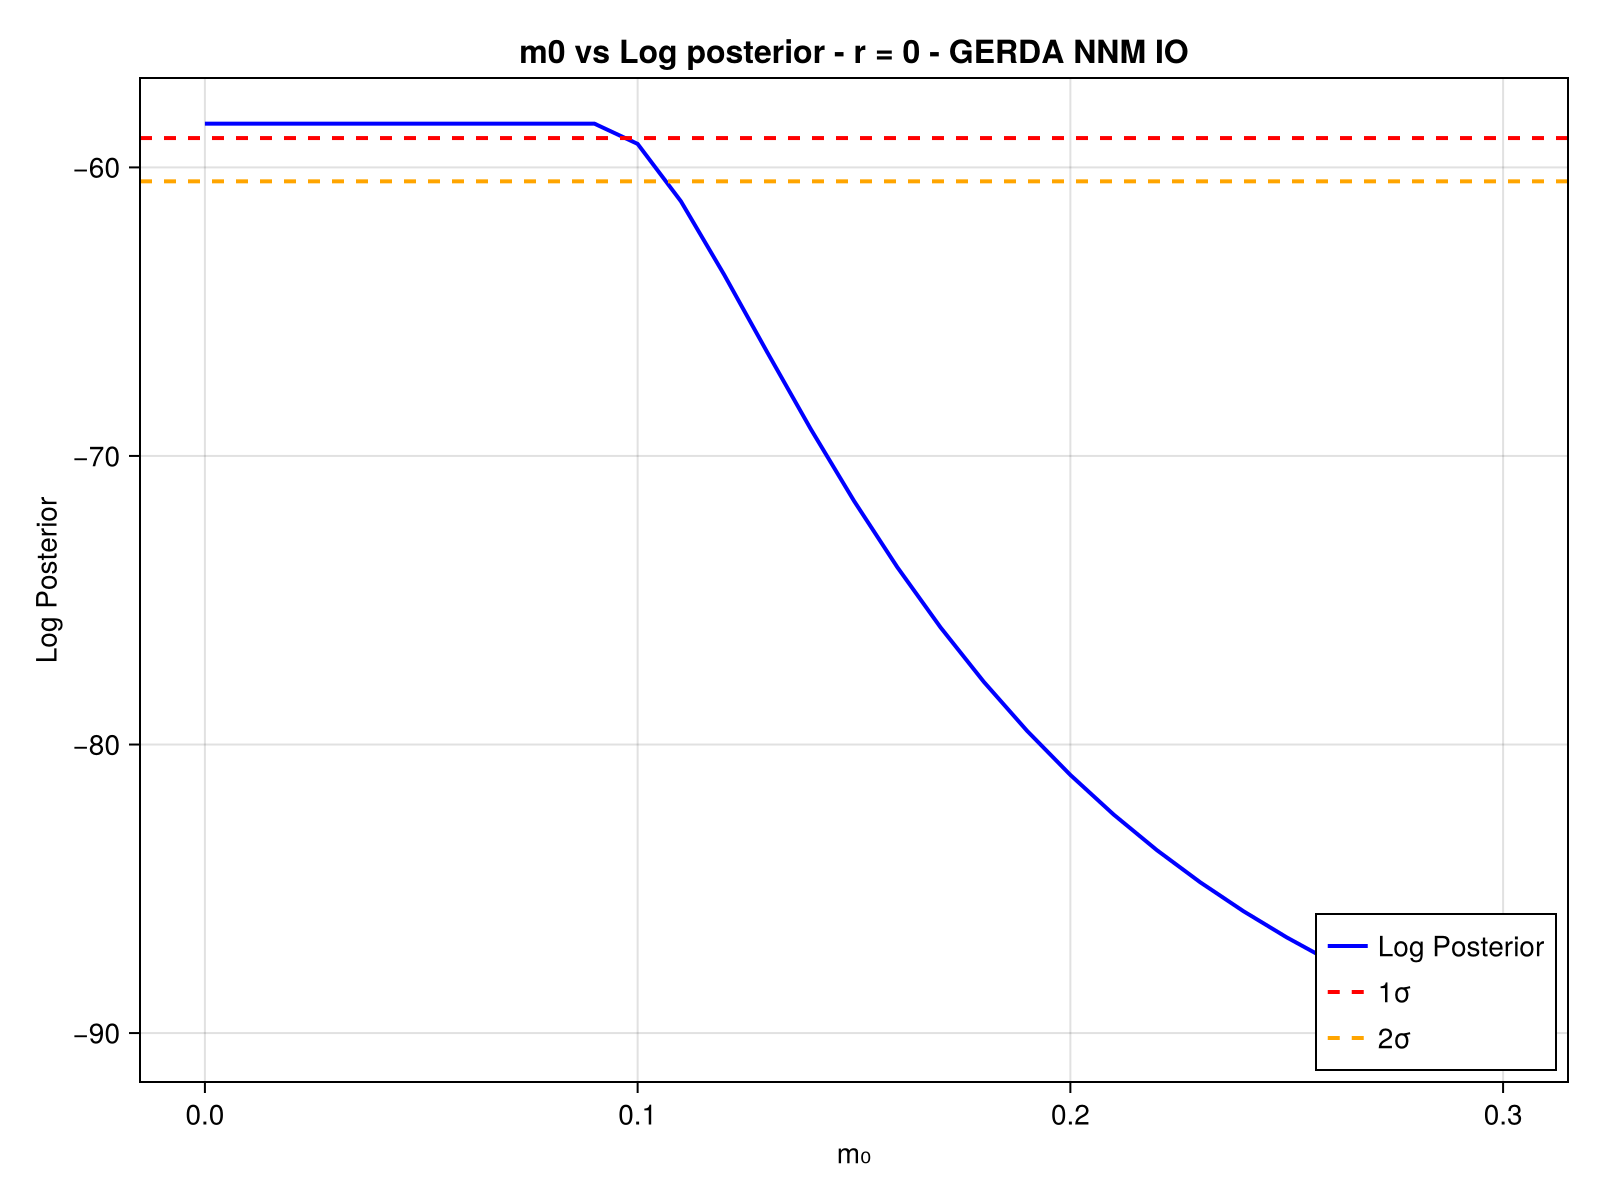

In [899]:
#plot the logposterior value vs r
result = result_NN

#value of r fixed
rfixed =  0#0.00000001
rmax=1
rindex = 1#round(Int, 31/rmax* rfixed)
println("rindex: ", rindex)

#calsculate the best fit
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterior[rindex ,: ]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterior[ rindex,: ]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  String(keys(result.axes)[2]),
    ylabel = "Log Posterior",
    title = "m0 vs Log posterior - r = $rfixed - GERDA NNM IO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.m₀, result.values.log_posterior[rindex , :],
    color = :blue,
    linewidth = 2,
    label = "Log Posterior"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/gerda_m0Logpost_NNM_IO_N=30_r=$rfixed.png", fig)


m0index: 16


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


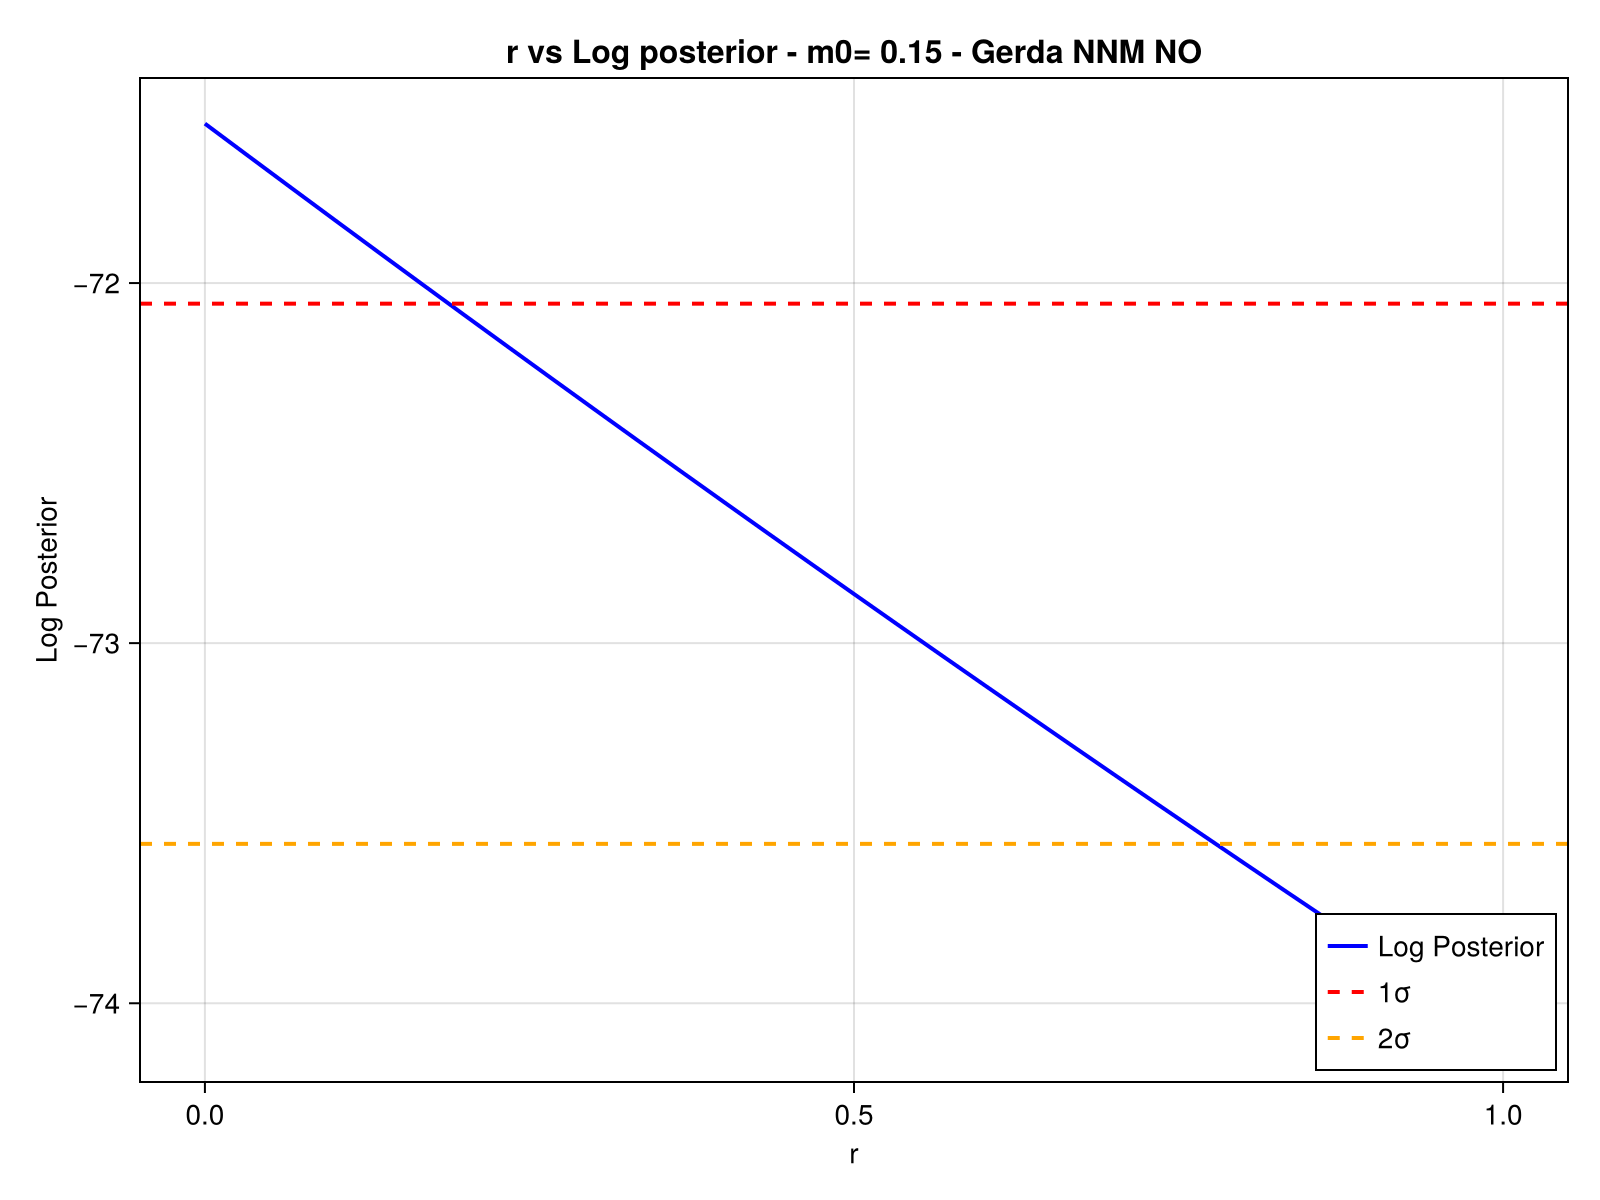

In [901]:

#value of m0 fixed
m0fixed =0.15
m0max=0.3
m0index = round(Int, 31/m0max* m0fixed)
println("m0index: ", m0index)

#calsculate the best fit
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterior[:, m0index ]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterior[:, m0index ]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  String(keys(result.axes)[1]),
    ylabel = "Log Posterior",
    title = "r vs Log posterior - m0= $m0fixed - Gerda NNM NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.r, result.values.log_posterior[:, m0index],
    color = :blue,
    linewidth = 2,
    label = "Log Posterior"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/gerda_rLogpost_NNM_IO_N=100_m0=$m0fixed.png", fig)
